# Instructions

- This homework assignment is worth **51** points. 
- Please strive for clarity and organization.
- **AI Usage**:
   - AI use is strictly **prohibited** for conceptual exercises.
   - For applied (Python) exercises, you may only use AI for **debugging**. Do not use AI to generate answers.
- **Due Date: September 18, 2026, by 11:59 PM.**

# Exercise 1 

In this exercise, we will work with the `winemag-data-130k-v2.csv` data file. This file contains information about wine. The goal is to explore this data using the NLP techniques that we have learnt. For more information about the data file, see this [link](https://www.kaggle.com/datasets/zynicide/wine-reviews/data).

### Exercise 1(a) (2 points)

Load the following libraries:

- `pandas`
- `numpy`
- `matplotlib.pyplot`
- `wordcloud`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud

### Exercise 1(b) (2 points)

Read the `csv` file and create a data-frame called `wine_df`.

In [2]:
wine_df = pd.read_csv("DATA/winemag-data-130k-v2.csv", index_col=0)
wine_df.head()

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


### Exercise 1(c) (2 points)

Report the `shape` of `wine_df`.

In [3]:
wine_df.shape

(129971, 13)

### Exercise 1(d) (2 points)

Report the number of wine types in the `wine_df` data frame.

In [4]:
wine_df["variety"].nunique()

707

### Exercise 1(e) (2 points)

Report the number countries producing wine in the `wine_df` data frame.

In [5]:
wine_df["country"].nunique()

43

### Exercise 1(f) (4 points)

Report the country with the highest and lowest average `points`.

In [6]:
avg_points = wine_df.groupby("country")["points"].mean()

print("Highest average points:", avg_points.idxmax(), round(avg_points.max(), 2))
print("Lowest average points: ", avg_points.idxmin(), round(avg_points.min(), 2))


Highest average points: England 91.58
Lowest average points:  Peru 83.56


### Exercise 1(g) (3 points)

Using the `string` library, remove all the punctuation of the `description` column and store the results in another column called `description_clean`.

In [7]:
import string

wine_df["description_clean"] = wine_df["description"].apply(
    lambda text: text.translate(str.maketrans("", "", string.punctuation))
)

wine_df[["description", "description_clean"]].head()

,description,description_clean
0,"Aromas include tropical fruit, broom, brimston...",Aromas include tropical fruit broom brimstone ...
1,"This is ripe and fruity, a wine that is smooth...",This is ripe and fruity a wine that is smooth ...
2,"Tart and snappy, the flavors of lime flesh and...",Tart and snappy the flavors of lime flesh and ...
3,"Pineapple rind, lemon pith and orange blossom ...",Pineapple rind lemon pith and orange blossom s...
4,"Much like the regular bottling from 2012, this...",Much like the regular bottling from 2012 this ...


### Exercise 1(h) (10 points)

Using the `nltk` library, remove stopwords, pronouns, and the following words: `drink`, `now`, `wine`, `flavor`, and `flavors` from `description_clean` and store in another column called `'description_clean_1'`. 

In [8]:
import nltk
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")   
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))

pronouns = {
    "i", "me", "my", "mine", "myself",
    "we", "us", "our", "ours", "ourselves",
    "you", "your", "yours", "yourself", "yourselves",
    "he", "him", "his", "himself",
    "she", "her", "hers", "herself",
    "it", "its", "itself",
    "they", "them", "their", "theirs", "themselves",
}

extra_words = {"drink", "now", "wine", "flavor", "flavors"}

words_to_remove = stop_words | pronouns | extra_words

def clean_text(text):
    tokens = word_tokenize(text.lower())
    return " ".join(word for word in tokens if word not in words_to_remove)

wine_df["description_clean_1"] = wine_df["description_clean"].apply(clean_text)

wine_df[["description_clean", "description_clean_1"]].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bdupey\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bdupey\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\bdupey\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,description_clean,description_clean_1
0,Aromas include tropical fruit broom brimstone ...,aromas include tropical fruit broom brimstone ...
1,This is ripe and fruity a wine that is smooth ...,ripe fruity smooth still structured firm tanni...
2,Tart and snappy the flavors of lime flesh and ...,tart snappy lime flesh rind dominate green pin...
3,Pineapple rind lemon pith and orange blossom s...,pineapple rind lemon pith orange blossom start...
4,Much like the regular bottling from 2012 this ...,much like regular bottling 2012 comes across r...


### Exercise 1(i) (6 points)

Create a data frame called `England` with wines from `England`, and create a word cloud of `description_clean_1`.

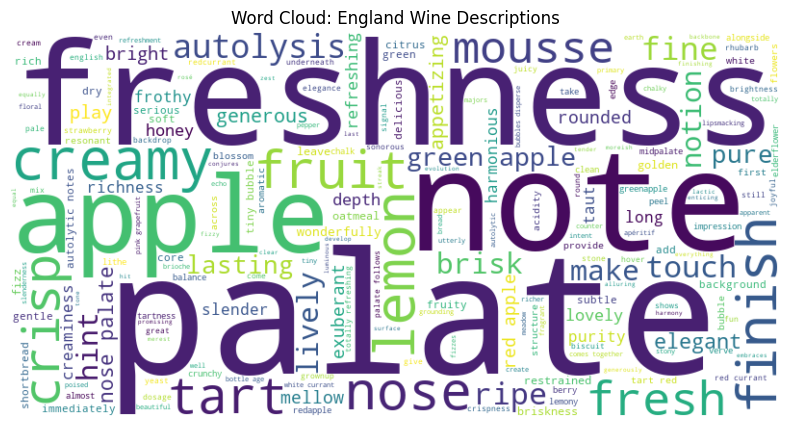

In [9]:
England = wine_df[wine_df["country"] == "England"]

england_text = " ".join(England["description_clean_1"])

wordcloud = WordCloud(width=800, height=400, background_color="white",
                      random_state=42).generate(england_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud: England Wine Descriptions")
plt.show()

### Exercise 1(j) (6 points)

Create a data frame called `Peru` with wines from `Peru`, and create a word cloud of `description_clean_1`.

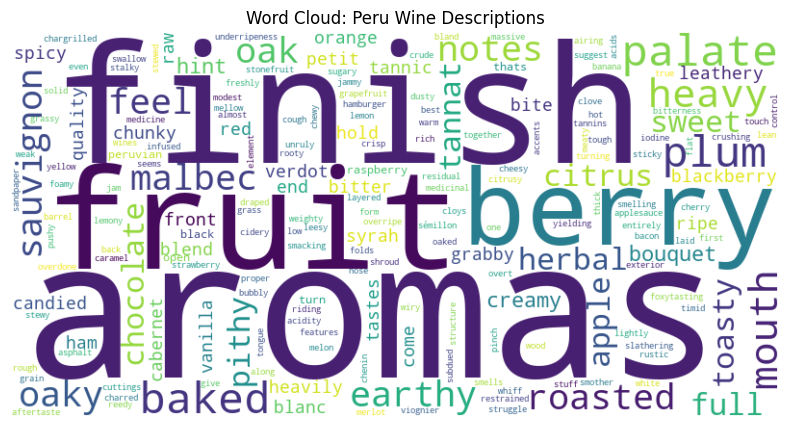

In [10]:
Peru = wine_df[wine_df["country"] == "Peru"]

peru_text = " ".join(Peru["description_clean_1"])

wordcloud = WordCloud(width=800, height=400, background_color="white",
                      random_state=42).generate(peru_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud: Peru Wine Descriptions")
plt.show()

# Exercise 2

In this exercise, we will test your conceptual understanding of the NLP pipeline discussed in class (Chapter 2). Answer each question in the markdown cell provided below it.

### Exercise 2(a) (4 points)

Explain the difference between **stemming** and **lemmatization**. In your answer, use the word "studies" to illustrate the difference in the outputs the two techniques produce, and describe a situation where lemmatization would be preferred over stemming.

Stemming chops off word endings with rules and can produce non-words: "studies" becomes "studi." Lemmatization returns the word's dictionary form: "studies" becomes "study." Lemmatization is preferred when the output will be read by people, such as a word cloud, where "studi" would be confusing

### Exercise 2(b) (4 points)

The wine reviews dataset in Exercise 1 is fairly balanced, but suppose instead we trained a classifier to flag fraudulent wine listings, where only 1% of listings in the training data are actually fraudulent. Explain why **accuracy** would be a misleading metric for evaluating this classifier, and identify two alternative metrics that would give a more meaningful picture of performance. Justify your choice.

because predicting "legitimate" for everything scores 99% while catching no fraud, so precision (how many flagged listings are really fraud) and recall (how much of the fraud gets caught) are better metrics.

### Exercise 2(c) (4 points)

After deploying a wine-review sentiment model, the team notices that reviews are increasingly written in short, emoji-heavy language that looks very different from the training data, even though positive and negative reviews still use largely the same vocabulary they always did. Is this an example of **data (covariate) drift** or **concept drift**? Justify your answer, and briefly describe how the team's response would differ if this were the other type of drift instead.

This is data (covariate) drift because the inputs changed while the word-to-sentiment relationship stayed the same, so the team retrains on new-style reviews; concept drift would mean the same words now signal different sentiment, requiring relabeling.